# 08. Torch 集成后的量子线路

用 PyTorch 管理参数和优化器，量子期望值由 UnifiedQuantum 线路和模拟器计算，梯度使用 parameter-shift 写回。


torch parameter: Parameter containing:
tensor(2.6185, requires_grad=True)
last rows: [(13, 2.160249948501587, -0.355, -0.9624999999999999), (14, 2.4099998474121094, -0.565, -0.8325), (15, 2.618499755859375, -0.725, -0.695)]


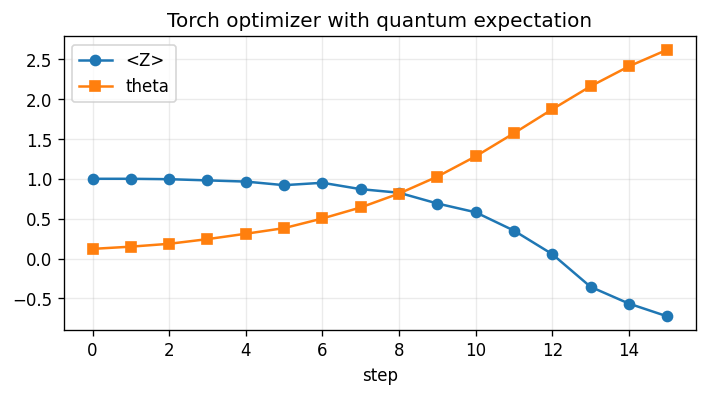

In [1]:
import math
import matplotlib.pyplot as plt
import torch

from uniqc import Circuit
from uniqc.simulator import OriginIR_Simulator

torch.manual_seed(7)

def circuit_for(theta):
    c = Circuit()
    c.ry(0, float(theta))
    c.measure(0)
    return c

def z_expectation(theta):
    counts = OriginIR_Simulator().simulate_shots(circuit_for(theta).originir, shots=400)
    total = sum(counts.values()) or 1
    return (counts.get(0, 0) - counts.get(1, 0)) / total

theta = torch.nn.Parameter(torch.tensor(0.1))
optimizer = torch.optim.SGD([theta], lr=0.3)
history = []

for step in range(16):
    optimizer.zero_grad()
    value = z_expectation(theta.item())
    grad = 0.5 * (
        z_expectation(theta.item() + math.pi / 2)
        - z_expectation(theta.item() - math.pi / 2)
    )
    theta.grad = torch.tensor(grad)
    optimizer.step()
    history.append((step, theta.item(), value, grad))

print("torch parameter:", theta)
print("last rows:", history[-3:])

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot([r[0] for r in history], [r[2] for r in history], marker="o", label="<Z>")
ax.plot([r[0] for r in history], [r[1] for r in history], marker="s", label="theta")
ax.set_xlabel("step")
ax.set_title("Torch optimizer with quantum expectation")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
